Carleton School of Information Technology

 Final project supplementary material: Prompt Injection Detection: Model Evaluation & Comparison

ITEC 5920 – Applied Deep Learning Winter 2026

Student: Michael Rolbin Student #100865849

## 1. Environment Setup

In [ ]:
# !pip install -q transformers datasets evaluate scikit-learn torch pandas matplotlib seaborn

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import torch

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from datasets import load_dataset
from transformers import pipeline
from sklearn.metrics import (
    f1_score,
    roc_auc_score,
    accuracy_score,
    recall_score,
    precision_score,
    classification_report,
    confusion_matrix,
)

## 2. Data Loading & Preprocessing


In [ ]:
print("Loading dataset from HuggingFace\\")
raw_dataset = load_dataset("neuralchemy/Prompt-injection-dataset")
print(raw_dataset)

# Inspect the first example to identify field names
first_example = raw_dataset[list(raw_dataset.keys())[0]][0]
print("\n--- First example  ---")
for k, v in first_example.items():
    print(f"  {k!r}: {str(v)[:120]}")

Loading dataset from HuggingFace\


DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'category', 'source', 'severity', 'group_id', 'augmented', 'tags'],
        num_rows: 4391
    })
    validation: Dataset({
        features: ['text', 'label', 'category', 'source', 'severity', 'group_id', 'augmented', 'tags'],
        num_rows: 941
    })
    test: Dataset({
        features: ['text', 'label', 'category', 'source', 'severity', 'group_id', 'augmented', 'tags'],
        num_rows: 942
    })
})

--- First example  ---
  'text': What are the best practices for secure coding in Python?
  'label': 0
  'category': benign
  'source': original
  'severity': 
  'group_id': grp_578f04597482
  'augmented': False
  'tags': ['coding', 'security_adjacent', 'hard_negative']


In [ ]:
# Adjust these constants if the dataset schema changes
TEXT_COLUMN  = "text"    # Column containing the raw prompt
LABEL_COLUMN = "label"   # Column containing the ground-truth label

INJECTION_TOKENS = {"INJECTION", "injection", "1", "LABEL_1"}

# Select the evaluation split (use 'test' if it exists, else 'train')
available_splits = list(raw_dataset.keys())
eval_split = "test" if "test" in available_splits else available_splits[0]
print(f"Using split: '{eval_split}'  (available: {available_splits})")

eval_data = raw_dataset[eval_split]

Using split: 'test'  (available: ['train', 'validation', 'test'])


In [ ]:
# Normalise labels to binary integers
#   injection / 1 / LABEL_1  →  1
#   benign    / 0 / LABEL_0  →  0
def normalise_ground_truth(label) -> int:
    """Map any dataset label representation to binary int (1=injection, 0=benign)."""
    if isinstance(label, int):
        return int(label > 0)
    label_str = str(label).strip().upper()
    if label_str in {"INJECTION", "1", "LABEL_1", "INJECTED", "PROMPT_INJECTION"}:
        return 1
    return 0


texts  = eval_data[TEXT_COLUMN]
labels = [normalise_ground_truth(lbl) for lbl in eval_data[LABEL_COLUMN]]

labels_array = np.array(labels)

print(f"Total evaluation examples : {len(texts)}")
print(f"Injection  (label=1)      : {labels_array.sum()}  "
      f"({labels_array.mean()*100:.1f}%)")
print(f"Benign     (label=0)      : {(1 - labels_array).sum()}  "
      f"({(1 - labels_array).mean()*100:.1f}%)")

Total evaluation examples : 942
Injection  (label=1)      : 552  (58.6%)
Benign     (label=0)      : 390  (41.4%)


## 3. Model Initialisation


In [ ]:

# Load models
DEVICE = 0 if torch.cuda.is_available() else -1
BATCH_SIZE = 32

MODEL_CONFIGS = {
    "ProtectAI": {
        "model_id"        : "protectai/deberta-v3-base-prompt-injection-v2",
        "injection_label" : "INJECTION",
    },
    "deepset": {
        "model_id"        : "deepset/deberta-v3-base-injection",
        "injection_label" : "INJECTION",
    },
}


def load_classifier(model_id: str) -> pipeline:
    """Load a text-classification pipeline."""
    print(f"  Loading '{model_id}' …")
    clf = pipeline(
        task="text-classification",
        model=model_id,
        device=DEVICE,
        truncation=True,
        max_length=512,
    )
    return clf


print("\nInitialising models…")
pipelines = {}
for name, cfg in MODEL_CONFIGS.items():
    pipelines[name] = load_classifier(cfg["model_id"])


Initialising models…
  Loading 'protectai/deberta-v3-base-prompt-injection-v2' …


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

  Loading 'deepset/deberta-v3-base-injection' …


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: deepset/deberta-v3-base-injection
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## 4. Inference


In [ ]:

# We run each pipeline over the full evaluation split and normalise the output to:
# - `y_pred`  — binary integer prediction (`1` = injection).
# - `y_score` — continuous probability for the injection class.

from tqdm.auto import tqdm

def run_inference(
    clf,
    texts: list[str],
    injection_label: str,
    batch_size: int = BATCH_SIZE,
) -> tuple[np.ndarray, np.ndarray]:

    all_outputs = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Batches"):
        batch = texts[i : i + batch_size]
        outputs = clf(batch)
        all_outputs.extend(outputs)

    y_pred  = []
    y_score = []

    for out in all_outputs:
        predicted_label = out["label"].upper()
        score           = out["score"]

        is_injection = int(predicted_label == injection_label.upper())
        y_pred.append(is_injection)

        # Convert model confidence into injection class probability
        injection_prob = score if is_injection else (1.0 - score)
        y_score.append(injection_prob)

    return np.array(y_pred), np.array(y_score)

# Run inference for both models
results_raw = {}

for name, cfg in MODEL_CONFIGS.items():
    print(f"\nRunning inference: {name}")
    y_pred, y_score = run_inference(
        clf=pipelines[name],
        texts=texts,
        injection_label=cfg["injection_label"],
    )
    results_raw[name] = {"y_pred": y_pred, "y_score": y_score}
    print(f"Predicted injections: {y_pred.sum()} / {len(y_pred)}")


Running inference: ProtectAI


Batches:   0%|          | 0/30 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Predicted injections: 488 / 942

Running inference: deepset


Batches:   0%|          | 0/30 [00:00<?, ?it/s]

Predicted injections: 701 / 942


## 5. Metric Calculation


In [ ]:
def compute_security_score(
    recall: float,
    f1: float,
    auc: float,
    accuracy: float,
) -> float:

    return round(0.4 * recall + 0.3 * f1 + 0.2 * auc + 0.1 * accuracy, 4)

def evaluate_model(
    model_name: str,
    y_true: np.ndarray,
    y_pred: np.ndarray,
    y_score: np.ndarray,
) -> dict:

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall    = recall_score(y_true, y_pred, zero_division=0)
    f1        = f1_score(y_true, y_pred, zero_division=0)
    accuracy  = accuracy_score(y_true, y_pred)
    auc       = roc_auc_score(y_true, y_score)
    sec_score = compute_security_score(recall, f1, auc, accuracy)

    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    print(classification_report(y_true, y_pred,
                                target_names=["Benign", "Injection"]))
    print(f"  AUC-ROC        : {auc:.4f}")
    print(f"  Security Score : {sec_score:.4f}")

    return {
        "Model"          : model_name,
        "Precision"      : round(precision, 4),
        "Recall"         : round(recall, 4),
        "F1-Score"       : round(f1, 4),
        "AUC-ROC"        : round(auc, 4),
        "Accuracy"       : round(accuracy, 4),
        "Security Score" : sec_score,
    }

# Evaluate both models
metrics_list = []
for name, raw in results_raw.items():
    metrics = evaluate_model(
        model_name=name,
        y_true=labels_array,
        y_pred=raw["y_pred"],
        y_score=raw["y_score"],
    )
    metrics_list.append(metrics)


  ProtectAI
              precision    recall  f1-score   support

      Benign       0.83      0.97      0.90       390
   Injection       0.98      0.86      0.92       552

    accuracy                           0.91       942
   macro avg       0.91      0.92      0.91       942
weighted avg       0.92      0.91      0.91       942

  AUC-ROC        : 0.9763
  Security Score : 0.9070

  deepset
              precision    recall  f1-score   support

      Benign       0.96      0.59      0.73       390
   Injection       0.77      0.98      0.87       552

    accuracy                           0.82       942
   macro avg       0.87      0.79      0.80       942
weighted avg       0.85      0.82      0.81       942

  AUC-ROC        : 0.9582
  Security Score : 0.9260


## 6. Comparison Table

In [ ]:
comparison_df = pd.DataFrame(metrics_list).set_index("Model")

styled = (
    comparison_df.style
    .highlight_max(axis=0, color="#d4edda")   # green for best
    .format("{:.4f}")
    .set_caption("Model Comparison — all metrics on the evaluation split")
)

display(styled)

,Precision,Recall,F1-Score,AUC-ROC,Accuracy,Security Score
Model,,,,,,
ProtectAI,0.9775,0.8641,0.9173,0.9763,0.9087,0.9070
deepset,0.7732,0.9819,0.8651,0.9582,0.8206,0.9260


## 7. Visualisation

### 7a. Security Score Bar Chart

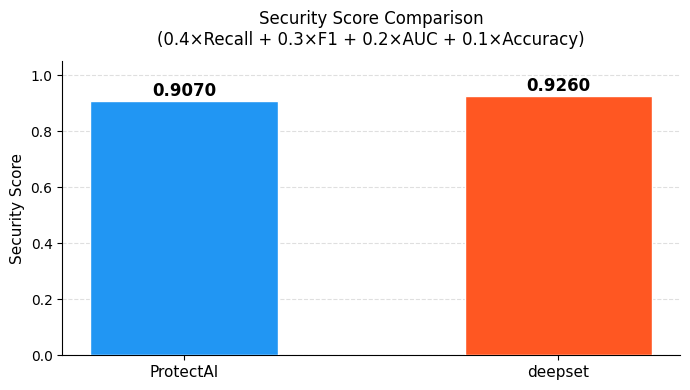

In [ ]:
PALETTE = ["#2196F3", "#FF5722"]

fig, ax = plt.subplots(figsize=(7, 4))

models        = comparison_df.index.tolist()
sec_scores    = comparison_df["Security Score"].tolist()
bar_positions = range(len(models))

bars = ax.bar(
    bar_positions,
    sec_scores,
    color=PALETTE,
    edgecolor="white",
    width=0.5,
    zorder=3,
)

for bar, score in zip(bars, sec_scores):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{score:.4f}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
    )

ax.set_xticks(list(bar_positions))
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Security Score", fontsize=11)
ax.set_title(
    "Security Score Comparison\n"
    r"(0.4×Recall + 0.3×F1 + 0.2×AUC + 0.1×Accuracy)",
    fontsize=12,
    pad=12,
)
ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("security_score_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### 7b. Multi-Metric Grouped Bar Chart

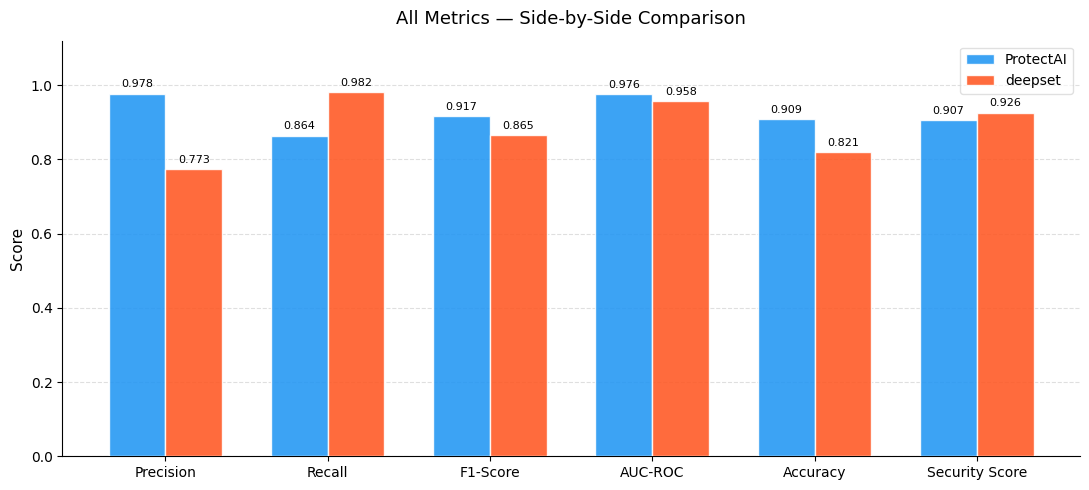

In [ ]:
METRICS_TO_PLOT = ["Precision", "Recall", "F1-Score", "AUC-ROC", "Accuracy", "Security Score"]

x = np.arange(len(METRICS_TO_PLOT))
width  = 0.35

fig, ax = plt.subplots(figsize=(11, 5))

for i, (model, color) in enumerate(zip(models, PALETTE)):
    values = [comparison_df.loc[model, m] for m in METRICS_TO_PLOT]
    offset = width * (i - 0.5)
    rects  = ax.bar(x + offset, values, width, label=model, color=color,
                    edgecolor="white", alpha=0.88, zorder=3)
    ax.bar_label(rects, fmt="%.3f", padding=3, fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(METRICS_TO_PLOT, fontsize=10)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("All Metrics — Side-by-Side Comparison", fontsize=13, pad=12)
ax.legend(fontsize=10, framealpha=0.6)
ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("all_metrics_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### 7c. Confusion Matrices

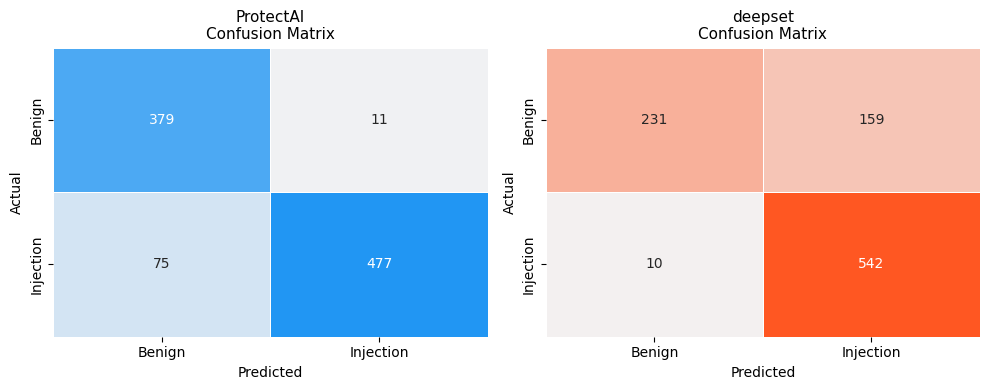

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (name, raw), color in zip(axes, results_raw.items(), PALETTE):
    cm = confusion_matrix(labels_array, raw["y_pred"])
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=sns.light_palette(color, as_cmap=True),
        xticklabels=["Benign", "Injection"],
        yticklabels=["Benign", "Injection"],
        linewidths=0.5,
        ax=ax,
        cbar=False,
    )
    ax.set_title(f"{name}\nConfusion Matrix", fontsize=11)
    ax.set_xlabel("Predicted", fontsize=10)
    ax.set_ylabel("Actual", fontsize=10)

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()